# Деревья решений: теория и практика

Данный ноутбук служит теоритеческим и практическим туториолом по модели машшиного обучения - деревья решений. Здесь будут описаны соновные принципы работы модели и выведены с нуля математические формулы работы алгоритма. Практическое применение модели есть в задачах Titanic, SalePrice

## Содержание:

## Введение: Интуиция

Дерево решений (Decision Tree) — это алгоритм машинного обучения, который строит модель в виде дерева. В каждом узле алгоритм задает вопрос к данным (например, "Значение признака $X_1 > 5$?"). В зависимости от ответа, мы идем в левую или правую ветвь, пока не дойдем до "листа", где находится итоговый прогноз.Преимущество деревьев — их интерпретируемость. Алгоритм естественным образом разбивает сложное пространство признаков на набор простых прямоугольных областей

# 1: Математика деревьев решений для классификации
Чтобы выбрать лучший признак и порог для разбиения данных, нам нужна метрика "загрязненности" (impurity) узла. Чем более однородны классы в узле, тем меньше загрязненность.

  

### 1.1. Энтропия Шеннона (Entropy)

Энтропия измеряет уровень неопределенности в системе. Если в узле $S$ находятся объекты $C$ классов, и $p_i$ — доля объектов класса $i$, то энтропия вычисляется как:

$$H(S) = -\sum_{i=1}^C p_i \log_2{(p_i)}$$

**Математический смысл:** Если все объекты в узле принадлежат одному классу (например, $p_1 = 1, p_2 = 0$), то $\log_2(1) = 0$, и энтропия $H = 0$ (неопределенности нет). Если классы распределены поровну ($p_1 = 0.5, p_2 = 0.5$), энтропия максимальна и равна $1$.

### 1.2. Прирост информации (Information Gain)

Чтобы оценить, насколько хорошим получилось разбиение узла $S$ на левого $S_{left}$ и правого $S_{right}$ потомков, мы используем Прирост Информации (IG). Он показывает, насколько уменьшилась энтропия после разбиения:

$$IG(S,A) = H(S) - \left( \frac{\vert{}S_{left}\vert{}}{\vert{}S\vert{}} H(S_{left}) + \frac{\vert{}S_{right}\vert{}}{\vert{}S\vert{}} H(S_{right}) \right)$$

Алгоритм ищет такой признак $A$ и такой порог разбиения, при котором $IG$ будет максимальным.

### 1.3. Критерий Джини (Gini Impurity)

Это альтернативная метрика, которая используется в `scikit-learn` по умолчанию. Она выводится из вероятности ошибки.

Представьте, что мы случайным образом выбираем объект из узла и присваиваем ему случайный класс, основываясь на распределении классов в узле.

Вероятность выбрать объект класса $i$ равна $p_i$. Вероятность ошибочно классифицировать его равна $(1 - p_i)$. Тогда общая вероятность ошибки:

$$Gini(S) = \sum_{i=1}^{C} p_{i} (1-p_{i}) = \sum_{i=1}^{C} (p_{i} - p_{i}^2)= \sum_{i=1}^{C}p_{i} - \sum_{i=1}^C p_{i}^2= 1 - \sum_{i=1}^C p_{i}^2$$

Критерий Джини вычислительно быстрее энтропии (так как не требует вычисления логарифма), поэтому чаще применяется на практике.

## 2: Реализация Дерева Решений с нуля

Теперь, понимая математику, ниже будет реализовано дерево классификации на Python.Будут использованны Энтропия и Прирост информации.

In [1]:
import numpy as np 

class Node:
    '''Узел дерева решений'''
    def __init__(self, feature=None, threshold=None,left=None,right=None,*,value=None):
        self.feature = feature       # Индекс признака для разбиения
        self.threshold = threshold   # Порог разбиения
        self.left = left             # Левое поддерево
        self.right = right           # Правое поддерево
        self.value = value           # Класс (если это лист)
    
    def is_leaf_node(self):
        return self.value is not None

class CustomDecisionTree:
    '''Модель дерева решений'''

    '''
    Это класс модели дерева решений. Внутри него есть методы:
        fit — обучить дерево;
        predict — сделать предсказания;
        _grow_tree — рекурсивно строит дерево;
        _best_split — ищет лучшее разбиение;
        _information_gain — считает информационный прирост;
        _split — делит данные на левую и правую части;
        _entropy — считает энтропию;
        _most_common_label — находит самый частый класс;
        _traverse_tree — проход по дереву при предсказании.
    Методы с _ необязательно вызывать снаружи напрямую, они вызываются другими функциями внутри класса
    '''
    
    def __init__(self, min_samples_split=2, max_depth=100):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.root = self._grow_tree(X,y)

    def _grow_tree(self, X, y, depth = 0):
        n_samples, n_feats = X.shape
        n_labels = len(np.unique(y))

        # Критерии остановки: достигнута макс. глубина, один класс в узле, мало сэмплов
        if (depth >= self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # Поиск лучшего разбиения
        best_feat, best_thresh = self._best_split(X,y,n_feats)

        # Если разбиение не улучшает ситуацию
        if best_feat is None:
            return Node(value=self._most_common_label(y))
        
        # Создание дочерних узлов
        left_idxs, right_idx = self._split(X[:, best_feat], best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._grow_tree(X[right_idx,:], y[right_idx], depth + 1)

        return Node(best_feat, best_thresh, left, right)

    def _best_split(self, X, y, n_feats):
        best_gain = -1
        split_idx, split_threshold = None, None

        for feat_idx in range(n_feats):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)

            for thr in thresholds:
                gain = self._information_gain(y, X_column, thr)

                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_threshold = thr

        return split_idx, split_threshold

    def _information_gain(self, y, X_column, threshold):
        # Энтропия родителя
        parent_entropy = self._entropy(y)

        # Разделение данных
        left_idxs, right_idxs = self._split(X_column, threshold)
        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # Взвешенная энтропия потомков
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        # Information Gain
        return parent_entropy - child_entropy

    def _split(self, X_column, split_thresh):
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist/len(y)
        return -np.sum([p*np.log2(p) for p in ps if p > 0])

    def _most_common_label(self, y):
        return np.bincount(y).argmax()

    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])

    def _traverse_tree(self, x, node):
        if node.is_leaf_node():
            return node.value
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)


    

# 3: Сравнение с scikit-learn и визуализация

Точность нашей модели: 0.8778
Точность sklearn модели: 0.8889


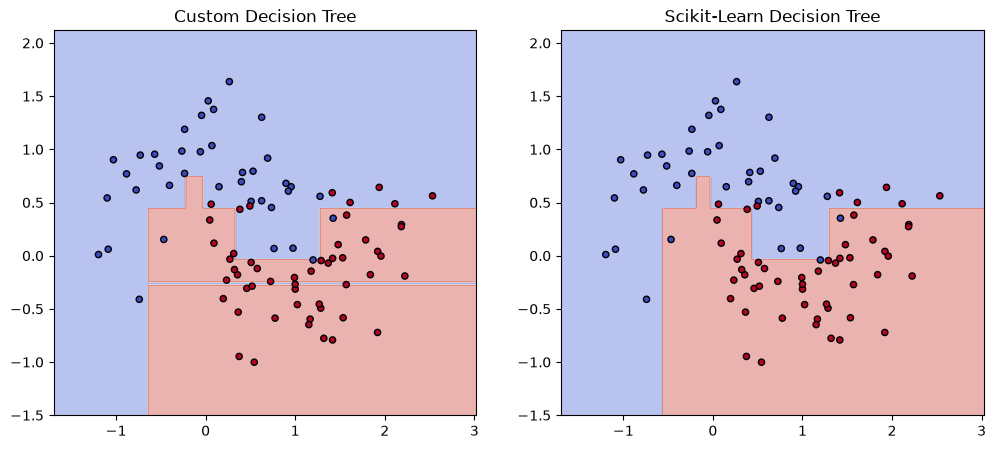

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

# 1. Генерация данных
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Обучение моделей
# написанная модель
custom_tree = CustomDecisionTree(max_depth=5)
custom_tree.fit(X_train, y_train)
custom_preds = custom_tree.predict(X_test)

# Модель scikit-learn
sklearn_tree = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
sklearn_tree.fit(X_train, y_train)
sklearn_preds = sklearn_tree.predict(X_test)

print(f"Точность написанной модели: {accuracy_score(y_test, custom_preds):.4f}")
print(f"Точность sklearn модели: {accuracy_score(y_test, sklearn_preds):.4f}")

# 3. Визуализация разделяющей поверхности
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='coolwarm')
    plt.title(title)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_decision_boundary(custom_tree, X_test, y_test, "Custom Decision Tree")
plt.subplot(1, 2, 2)
plot_decision_boundary(sklearn_tree, X_test, y_test, "Scikit-Learn Decision Tree")
plt.show()

Результаты обеих моделей практически идентичны, так как они реализуют одну и ту же математическую логику (при условии одинаковых гиперпараметров).

# 4: модель в sklearn
В библиотеке scikit-learn (модуль sklearn.tree) деревья решений представлены двумя основными классами:

- DecisionTreeClassifier — для задач классификации (предсказание категорий/меток).

- DecisionTreeRegressor — для задач регрессии (предсказание непрерывных чисел).

## 1. Главные гиперпараметры (Параметры модели)

Большинство параметров совпадает у обеих моделей. Они делятся на группы по смыслу.

### А. Критерии качества сплита (`criterion`)

Определяет функцию потерь / загрязненности узла, по которой алгоритм ищет лучший сплит:

* **Для `DecisionTreeClassifier`:**
* `'gini'` (по умолчанию): Критерий Джини. Быстрый в вычислении, стандартный выбор.
* `'entropy'` или `'log_loss'`: Энтропия Шеннона / Кросс-энтропия.


* **Для `DecisionTreeRegressor`:**
* `'squared_error'` (по умолчанию): Среднеквадратичная ошибка (MSE). Значением в листе станет среднее арифметическое $\bar{y}$.
* `'absolute_error'`: Средняя абсолютная ошибка (MAE). Значением в листе станет медиана. Более робастна к выбросам.
* `'friedman_mse'`: Улучшенная версия MSE Фридмана.
* `'poisson'`: Отклонение Пуассона (для целевых переменных, выражающих счетные данные $\ge 0$).



### Б. Ограничение сложности (Защита от переобучения)

Деревья без ограничений легко переобучаются (заучивают выборку до $100\%$ точности). Для регуляризации настраивают следующие параметры:

* **`max_depth`** (`int` или `None`, по умолчанию `None`): Максимальная глубина дерева. *Как выбирать:* Если `None`, дерево растет до полной чистоты листьев. Для предотвращения переобучения обычно ставят от `3` до `10` в зависимости от размера данных.


* **`min_samples_split`** (`int` или `float`, по умолчанию `2`): Минимальное количество объектов в узле, необходимое для того, чтобы узел мог дальше разветвиться. Если передать `float` (например, `0.05`), расценивается как доля от общего числа объектов ($5\%$).


* **`min_samples_leaf`** (`int` или `float`, по умолчанию `1`): Минимальное количество объектов, которое должно оказаться в создаваемом листе. *Совет:* Значения `5–20` существенно сглаживают модель и предотвращают выделение аномальных выбросов в отдельные листья.


* **`max_leaf_nodes`** (`int` или `None`, по умолчанию `None`): Ограничение на максимальное итоговое количество листьев в дереве.


* **`min_impurity_decrease`** (`float`, по умолчанию `0.0`): Узел будет делиться только в том случае, если сплит уменьшит загрязненность (Impurity) минимум на эту величину.



### В. Пост-стрижка дерева (Pruning)

* **`ccp_alpha`** (`float` $\ge 0.0$, по умолчанию `0.0`): Параметр сложности для Cost-Complexity Pruning. Выращивает полное дерево, а затем удаляет слабые ветки, штрафуя за количество листьев. Больше `ccp_alpha` $\implies$ проще и короче дерево.



### Г. Случайность и признаковое пространство

* **`max_features`** (`int`, `float`, `'sqrt'`, `'log2'` или `None`, по умолчанию `None`): Число признаков, проверяемых при поиске лучшего сплита. `None`: проверяются абсолютно все признаки. `'sqrt'`: проверяется $\sqrt{P}$ случайных признаков (часто используется в Random Forest).


* **`splitter`** (`'best'` или `'random'`, по умолчанию `'best'`): Стратегия выбора сплита. `'best'` ищет идеальный порог, `'random'` берет случайный порог из диапазона значений признака.


* **`random_state`** (`int`, по умолчанию `None`): Фиксирует генератор случайных чисел для воспроизводимости результатов.



### Д. Специфично для классификации

* **`class_weight`** (`dict`, `'balanced'` или `None`, по умолчанию `None`):Веса классов при дисбалансе.`'balanced'`: автоматически перевзвешивает классы обратно пропорционально их частоте в данных ($w_j = \frac{N}{K \cdot N_j}$).


In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

# 1. Генерация синтетических данных регрессии
X, y = make_regression(n_samples=500, n_features=5, noise=15.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Инициализация модели
reg = DecisionTreeRegressor(
    criterion='squared_error', # Критерий качества ('squared_error' или 'absolute_error')
    max_depth=5,               # Глубина дерева
    min_samples_split=10,      # Нужно минимум 10 объектов в узле для сплита
    min_samples_leaf=5,        # Минимум 5 объектов в листе
    random_state=42
)

# 3. Обучение
reg.fit(X_train, y_train)

# 4. Предсказание
y_pred = reg.predict(X_test)   # Массив непрерывных чисел

# 5. Оценка качества
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE (Корень из средней квадратичной ошибки): {rmse:.2f}")
print(f"R^2 Score (Детерминация): {r2:.4f}")

RMSE (Корень из средней квадратичной ошибки): 55.66
R^2 Score (Детерминация): 0.7416


In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_leaf': [1, 2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,               # 5-fold кросс-валидация
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Лучшие параметры:", grid_search.best_params_)
best_model = grid_search.best_estimator_

Лучшие параметры: {'max_depth': None, 'min_samples_leaf': 1}


# 5: дерево решений для регрессии 

## 1. Как дерево регрессии принимает решение (Прогноз в листе)

Формально модель дерева регрессии записывается так:


$$\hat{y} = f(x) = \sum_{m=1}^{M} c_m \cdot \mathbb{I}(x \in R_m)$$

Где:

* $R_m$ — $m$-я область (лист дерева).
* $\mathbb{I}(x \in R_m)$ — индикаторная функция (равна $1$, если объект $x$ попал в лист $R_m$, и $0$ в противном случае).
* $c_m$ — значение (решение) листа.

**Как вычисляется $c_m$?**
Значение константы $c_m$ напрямую зависит от выбранной функции потерь $L(y, \hat{y})$. Мы ищем такое $c_m$, которое минимизирует суммарную ошибку на объектах, попавших в лист $R_m$:


$$c_m^* = \arg\min_{c} \sum_{i \in R_m} L(y_i, c)$$

---

## 2. Основные функции потерь и математический вывод решений

### 2.1. L2-Loss / MSE (Mean Squared Error) — Стандарт по умолчанию

Это самая популярная функция потерь в регрессионных деревьях (в `scikit-learn` параметр `criterion='squared_error'`).

**Функция потерь для листа $R_m$:**


$$L_{MSE}(c) = \frac{1}{\vert{}R_m\vert{}} \sum_{i \in R_m} (y_i - c)^2$$

**Математический вывод значения листа $c_m^*$:**
Найдем минимум функции $L_{MSE}(c)$, приравняв ее производную по $c$ к нулю:


$$\frac{d}{dc} \sum_{i \in R_m} (y_i - c)^2 = 0$$

$$-2 \sum_{i \in R_m} (y_i - c) = 0$$

$$\sum_{i \in R_m} y_i - \sum_{i \in R_m} c = 0$$

$$\sum_{i \in R_m} y_i - \vert{}R_m\vert{} \cdot c = 0 \implies c_m^* = \frac{1}{\vert{}R_m\vert{}} \sum_{i \in R_m} y_i = \bar{y}_m$$

> **Вывод 1:** При использовании MSE значение в листе $c_m$ равно среднему арифметическому целевой переменной среди всех объектов этого листа.

**Критерий разбиения узла (Variance Reduction):**
При MSE критерий выбора лучшего сплита эквивалентен максимальному снижению дисперсии (Variance Reduction). Ошибка узла $S$ равна дисперсии целевой переменной в нем $\operatorname{Var}(y_S)$. Дерево ищет такой признак и порог, чтобы минимизировать:


$$Q(S, A) = \frac{\vert{}S_L\vert{}}{\vert{}S\vert{}} \operatorname{Var}(y_{S_L}) + \frac{\vert{}S_R\vert{}}{\vert{}S\vert{}} \operatorname{Var}(y_{S_R}) \to \min$$

---

### 2.2. L1-Loss / MAE (Mean Absolute Error) — Робастный критерий

Применяется, когда в данных есть аномальные выбросы, которые квадратичный штраф MSE исказил бы слишком сильно (в `scikit-learn` параметр `criterion='absolute_error'`).

**Функция потерь для листа $R_m$:**


$$L_{MAE}(c) = \frac{1}{\vert{}R_m\vert{}} \sum_{i \in R_m} \vert{}y_i - c\vert{}$$

**Математический вывод значения листа $c_m^*$:**
Функция $\vert{}y_i - c\vert{}$ недифференцируема в точке $c = y_i$, поэтому используем субградиент:


$$\frac{\partial}{\partial c} \sum_{i \in R_m} \vert{}y_i - c\vert{} = \sum_{i \in R_m} \operatorname{sign}(c - y_i) = 0$$


Субградиент равен нулю только тогда, когда количество объектов, где $y_i < c$, равно количеству объектов, где $y_i > c$.

> **Вывод 2:** При использовании MAE значение в листе $c_m$ равно медиане целевой переменной среди объектов этого листа:
> 
> $$c_m^* = \text{median}(\{y_i \mid i \in R_m\})$$
> 
> 

---

### 2.3. Huber Loss (Гибридный критерий)

Сочетает в себе преимущества MSE и MAE: работает как MSE при малых ошибках и как MAE при больших.

$$L_{\delta}(y, c) = \begin{cases} \frac{1}{2}(y - c)^2, & \vert{}y - c\vert{} \le \delta \\ \delta \cdot \left(\vert{}y - c\vert{} - \frac{1}{2}\delta\right), & \vert{}y - c\vert{} > \delta \end{cases}$$

* **Свойства:** Гладкая функция во всей области определения, устойчивая к выбросам.
* **Решение в листе:** Находится численно методом Ньютона или градиентного спуска.

---

### 2.4. Poisson Deviance (Отклонение Пуассона)

Применяется, если целевая переменная $y \ge 0$ выражает счетные данные (количество продаж за день, число звонков в колл-центр, количество кликов).

$$L(y, c) = 2 \cdot \left( y \ln \left(\frac{y}{c}\right) - y + c \right)$$

* **Решение в листе:** $c_m^* = \bar{y}_m$ (среднее), но разбиения строятся с учетом пуассоновского распределения данных.

# 5: Cost-Complexity Pruning (CCP)
**Cost-Complexity Pruning (CCP)**, или «стрижка с учетом стоимости и сложности», — это элегантный математический метод. Его суть заключается в том, чтобы не просто обрезать дерево наугад, а ввести **налог на сложность** (штраф за каждый лист) и посмотреть, какие ветки «обанкротятся» первыми.

Давайте разберем математику этого процесса шаг за шагом.

---

### 1. Главная формула (Функционал стоимости-сложности)

Для любого дерева (или поддерева) $T$ мы можем вычислить его **Cost-Complexity Score** по следующей формуле:

$$R_\alpha(T) = R(T) + \alpha \cdot \vert{}T\vert{}$$

Где:

* **$R(T)$** — суммарная ошибка дерева (Cost). В классификации это взвешенная сумма «загрязненности» (например, Gini) всех листьев. В регрессии — сумма MSE.
* **$\vert{}T\vert{}$** — количество листьев в дереве (Complexity).
* **$\alpha$** — параметр штрафа (налог). Сколько «единиц ошибки» мы готовы простить дереву, если оно избавится от одного листа.

**Идея:** Пока $\alpha = 0$, мы смотрим только на ошибку $R(T)$, и выигрывает самое большое дерево. Но если $\alpha$ начинает расти, огромные деревья получают гигантский штраф $\alpha \cdot \vert{}T\vert{}$, и математически выгоднее становится иметь короткое дерево с чуть большей ошибкой $R(T)$.

---

### 2. Как алгоритм ищет «самую слабую ветку»?

Любой внутренний узел-развилку $t$ где-то в середине дерева. Из него растет поддерево $T_t$. У алгоритма есть выбор:

1. **Оставить как есть:** Тогда у нас есть поддерево $T_t$, в котором несколько листьев ($\vert{}T_t\vert{}$).
2. **Схлопнуть (обрезать):** Превратить сам узел $t$ в один-единственный лист.

Давайте посчитаем Cost-Complexity для обоих вариантов.

* Если мы **оставим** поддерево, его скор будет:  
$$R_\alpha(T_t) = R(T_t) + \alpha \cdot \vert{}T_t\vert{}$$


* Если мы его **схлопнем**, оно превратится в 1 лист. Ошибка возрастет и станет равна $R(t)$, но зато листьев станет всего $1$. Скор будет: 
$$R_\alpha(t) = R(t) + \alpha \cdot 1$$



Понятно, что ошибка схлопнутого узла всегда больше ошибки разветвленного дерева ($R(t) \ge R(T_t)$). Но при достаточно большом штрафе $\alpha$ **схлопнутый вариант станет выгоднее**.

Найдем точку равновесия (когда стоимости равны):


$$R(t) + \alpha = R(T_t) + \alpha \cdot \vert{}T_t\vert{}$$

Решаем это уравнение относительно $\alpha$:


$$\alpha \cdot \vert{}T_t\vert{} - \alpha = R(t) - R(T_t)$$

$$\alpha \cdot (\vert{}T_t\vert{} - 1) = R(t) - R(T_t)$$

И получаем главную формулу алгоритма — **Эффективную Альфу ($\alpha_{eff}$)**:

$$\alpha_{eff}(t) = \frac{R(t) - R(T_t)}{\vert{}T_t\vert{} - 1}$$

---

### 3. Что физически значит эта формула?

Посмотрите на дробь $\alpha_{eff}(t)$:

* **Числитель $R(t) - R(T_t)$:** Это то, **насколько снизилась ошибка** благодаря тому, что мы позволили узлу разветвиться в поддерево.
* **Знаменатель $\vert{}T_t\vert{} - 1$:** Это то, **сколько дополнительных листьев** нам пришлось для этого создать.

> **Вывод:** $\alpha_{eff}$ — это **удельная польза**. Она показывает, насколько снижается ошибка дерева *в расчете на каждый дополнительно созданный лист* в этой ветке.

**Самая слабая ветка (Weakest Link)** — это тот узел $t$, у которого значение $\alpha_{eff}$ **минимально**. Это означает, что данное поддерево плодит кучу листьев, но почти не улучшает качество предсказания (скорее всего, оно просто запомнило случайный шум).

---

### 4. Алгоритм стрижки (Шаг за шагом)

Вот что именно делает метод `clf.cost_complexity_pruning_path(X, y)` под капотом `scikit-learn`:

1. Строится полное дерево (без ограничений).
2. Для **каждого** внутреннего узла $t$ по формуле вычисляется его $\alpha_{eff}$.
3. Находится узел с **наименьшим** $\alpha_{eff}$.
4. Это поддерево безжалостно отрезается (узел превращается в лист). Дерево становится чуть меньше.
5. Значение этой минимальной $\alpha_{eff}$ записывается в массив (тот самый `ccp_alphas` из предыдущего ответа).
6. Шаги 2–5 повторяются рекурсивно до тех пор, пока от огромного дерева не останется только один корневой узел.

В результате мы получаем последовательность вложенных деревьев от самого сложного к самому простому и соответствующий им список критических порогов `ccp_alphas`. Нам остается только проверить каждое из этих деревьев на тестовой выборке и выбрать то, где Accuracy максимальна!

Оптимальное значение ccp_alpha: 0.00460
Максимальная точность на тесте: 0.9580
Глубина лучшего дерева: 4 (против 7 у полного)


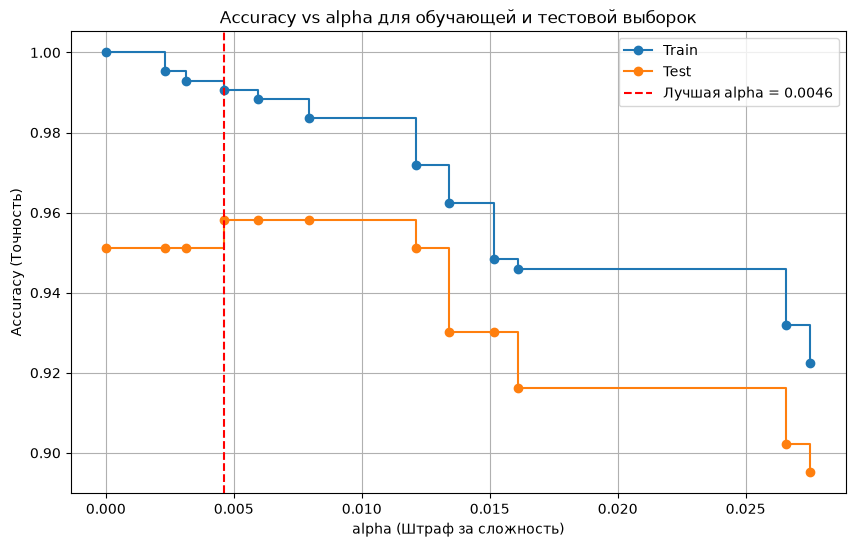

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# 1. Загрузка данных (Используем датасет рака молочной железы)
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# 2. Получение эффективных значений ccp_alpha
# Обучаем базовое дерево (без ограничений), чтобы scikit-learn рассчитал все пороги отсечения
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas # Массив возможных значений alpha

# Убираем последнее значение, так как оно соответствует дереву из 1 узла (полное недообучение)
ccp_alphas = ccp_alphas[:-1] 

# 3. Обучение деревьев для каждого значения ccp_alpha
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    clfs.append(clf)

# 4. Сбор метрик Accuracy (Точности)
train_scores = [clf.score(X_train, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

# Находим индекс дерева с максимальной точностью на тестовой выборке
best_idx = np.argmax(test_scores)
best_alpha = ccp_alphas[best_idx]
best_test_score = test_scores[best_idx]

print(f"Оптимальное значение ccp_alpha: {best_alpha:.5f}")
print(f"Максимальная точность на тесте: {best_test_score:.4f}")
print(f"Глубина лучшего дерева: {clfs[best_idx].get_depth()} (против {clfs[0].get_depth()} у полного)")

# 5. Визуализация: зависимость точности от ccp_alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel("alpha (Штраф за сложность)")
ax.set_ylabel("Accuracy (Точность)")
ax.set_title("Accuracy vs alpha для обучающей и тестовой выборок")
ax.plot(ccp_alphas, train_scores, marker='o', label="Train", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="Test", drawstyle="steps-post")

# Отмечаем лучшую точку
ax.axvline(best_alpha, linestyle="--", color="red", label=f"Лучшая alpha = {best_alpha:.4f}")
ax.legend()
plt.grid(True)
plt.show()